In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Paths
BASE = '/data1/project2/yeonu/cirrhosis'
MULTI = f'{BASE}/multiome'
GEOMX = f'{BASE}/geomx'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load Multiome metadata ──
rna_meta = pd.read_csv(f'{MULTI}/rna_cell_metadata.csv', index_col=0)
umap_df  = pd.read_csv(f'{MULTI}/umap_celltype.csv', index_col=0)

# Merge UMAP coords into rna_meta
df = rna_meta.join(umap_df[['UMAP_1', 'UMAP_2']], how='left')

# ── Load GeoMx metadata ──
geo_meta = pd.read_csv(f'{GEOMX}/segment_meta_merged_with_groups.csv')
geo_expr = pd.read_csv(f'{GEOMX}/expression_matrix_q3.csv')

print(f'Multiome cells : {len(df):,}')
print(f'GeoMx segments : {len(geo_meta):,}')
print(f'GeoMx genes    : {len(geo_expr):,}')

Multiome cells : 28,859
GeoMx segments : 88
GeoMx genes    : 16,818


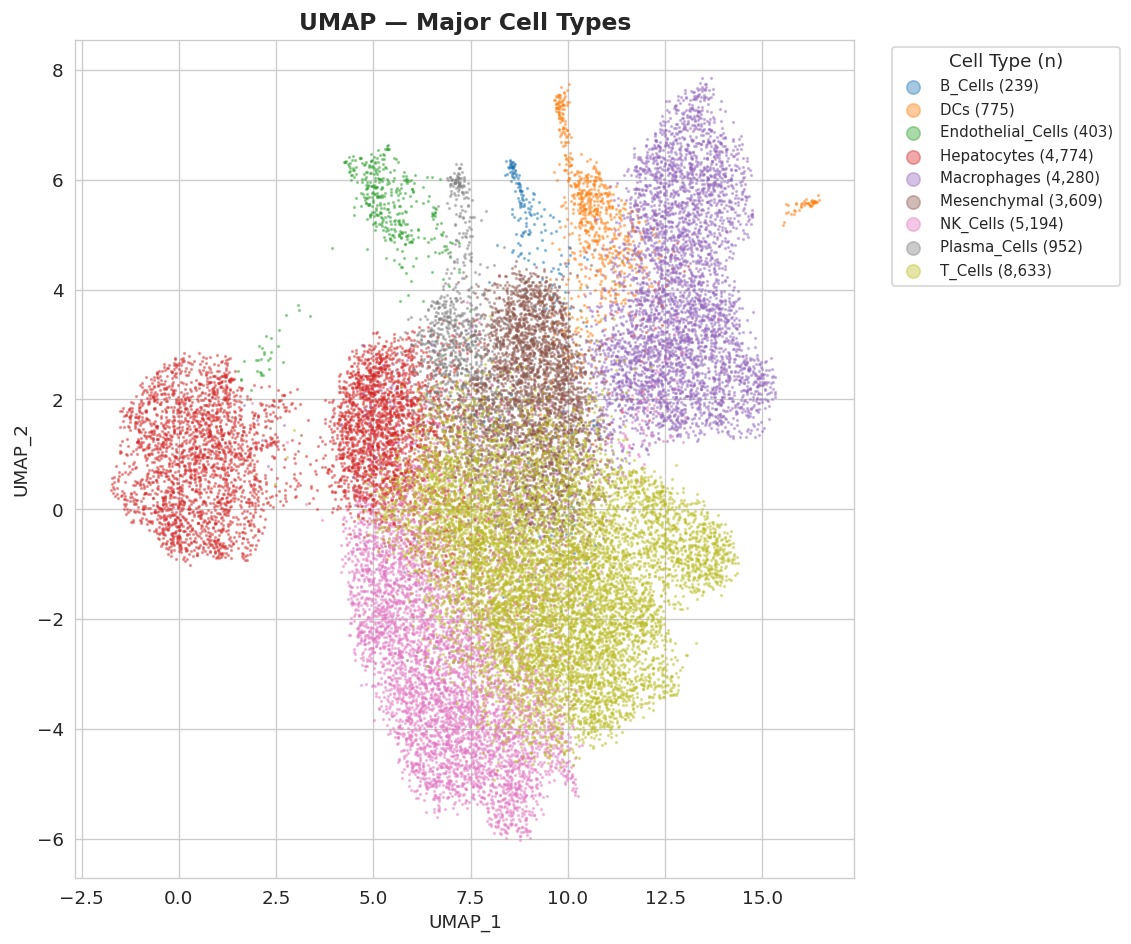

In [4]:
# ── 3.1 UMAP — Major Cell Types ──
umap_valid = df.dropna(subset=['UMAP_1', 'UMAP_2'])

celltypes = sorted(umap_valid['celltype_assign'].dropna().unique())
n_ct = len(celltypes)
ct_cmap = plt.cm.get_cmap('tab10', max(n_ct, 10))
ct_colors = {ct: ct_cmap(i) for i, ct in enumerate(celltypes)}

fig, ax = plt.subplots(figsize=(10, 8))

# Shuffle for better visibility
plot_df = umap_valid.sample(frac=1, random_state=42)

for ct in celltypes:
    sub = plot_df[plot_df['celltype_assign'] == ct]
    ax.scatter(sub['UMAP_1'], sub['UMAP_2'], s=1, alpha=0.4,
              color=ct_colors[ct], label=f'{ct} ({len(sub):,})')

ax.set_title('UMAP — Major Cell Types', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP_1')
ax.set_ylabel('UMAP_2')
ax.legend(markerscale=8, fontsize=9, loc='upper right',
          bbox_to_anchor=(1.35, 1.0), title='Cell Type (n)')

plt.tight_layout()
plt.show()

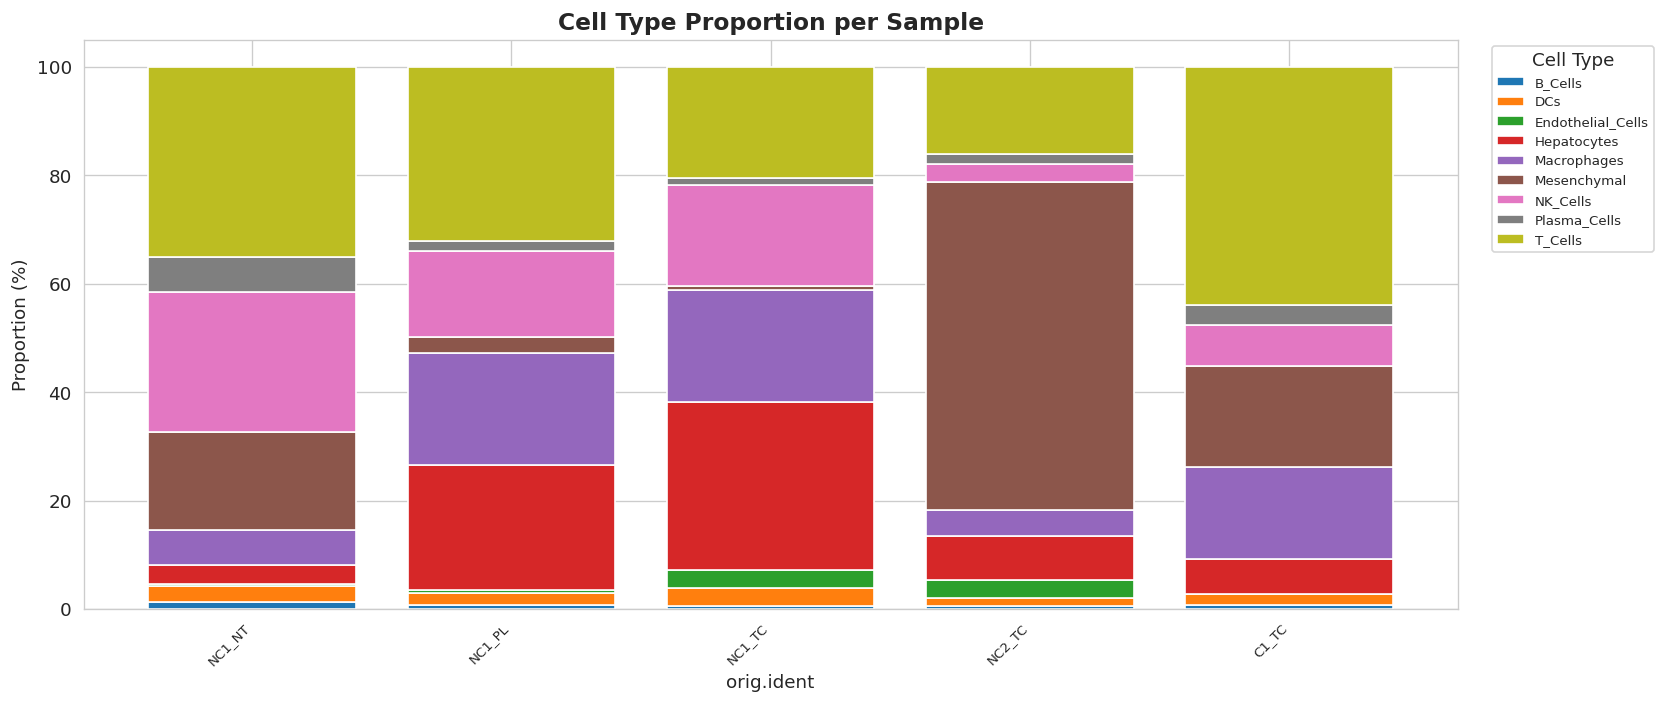

In [5]:
# ── 3.2b Cell Type Proportions per Sample ──
ct_sample = pd.crosstab(df['orig.ident'], df['celltype_assign'], normalize='index') * 100
sample_order = ['NC1_NT', 'NC1_PL', 'NC1_TC', 'NC2_TC', 'C1_TC']
sample_order = [s for s in sample_order if s in ct_sample.index]
ct_sample = ct_sample.loc[sample_order]

fig, ax = plt.subplots(figsize=(14, 6))
ct_sample[celltypes].plot.bar(stacked=True, ax=ax,
                               color=[ct_colors.get(ct, '#999') for ct in celltypes],
                               width=0.8)
ax.set_ylabel('Proportion (%)')
ax.set_title('Cell Type Proportion per Sample', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1.0), loc='upper left', title='Cell Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()